In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

df = pd.read_csv("/content/provider_fraud_risk.csv", sep=";")

df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,unique_procedures,total_beneficiaries,total_services,avg_submitted_charge,avg_medicare_payment,avg_payment_gap,services_per_beneficiary,service_percentile,charge_percentile,payment_percentile,services_per_bene_percentile,payment_gap_percentile,fraud_risk_score
0,1447357769,Mchenry,Michael,Addiction Medicine,OH,1,63.0,106.0,8.000000,7.840000,0.160000,1.682540,29,1,2,26,1,13.35
1,1447298120,Vandoren,Bryan,Addiction Medicine,OK,1,198.0,586.0,25.000000,11.270546,13.729454,2.959596,34,3,4,30,2,16.40
2,1194254441,Lyon,Jacob,Addiction Medicine,WV,1,25.0,27.0,21.481481,5.289630,16.191852,1.080000,16,2,1,16,3,8.25
3,1689634115,Mcginnis,David,Addiction Medicine,MA,1,13.0,13.0,34.000000,8.290000,25.710000,1.000000,3,4,3,2,4,3.20
4,1053334219,Waller,Andrew,Addiction Medicine,VA,1,38.0,121.0,40.000000,12.350000,27.650000,3.184211,32,5,5,31,5,17.00


In [13]:
print(df.shape)

(344734, 18)


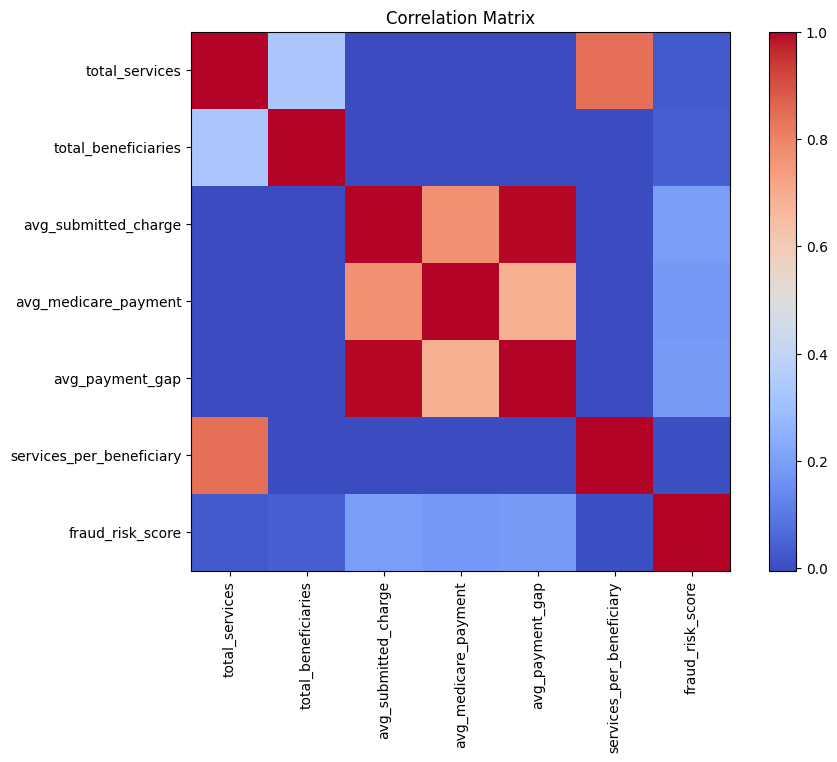

                          total_services  total_beneficiaries  \
total_services                  1.000000             0.332033   
total_beneficiaries             0.332033             1.000000   
avg_submitted_charge           -0.005199            -0.003534   
avg_medicare_payment           -0.004240            -0.001384   
avg_payment_gap                -0.005116            -0.003761   
services_per_beneficiary        0.840704            -0.000417   
fraud_risk_score                0.027684             0.041104   

                          avg_submitted_charge  avg_medicare_payment  \
total_services                       -0.005199             -0.004240   
total_beneficiaries                  -0.003534             -0.001384   
avg_submitted_charge                  1.000000              0.769091   
avg_medicare_payment                  0.769091              1.000000   
avg_payment_gap                       0.992670              0.686209   
services_per_beneficiary             -0.004433 

In [14]:
#Correlation Analysis
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = [
    "total_services",
    "total_beneficiaries",
    "avg_submitted_charge",
    "avg_medicare_payment",
    "avg_payment_gap",
    "services_per_beneficiary",
    "fraud_risk_score"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

print(corr)

In [17]:
top_specialties = (
    df.groupby("Rndrng_Prvdr_Type")
      .agg(
          Average_Risk=("fraud_risk_score","mean"),
          Providers=("Rndrng_NPI","count")
      )
      .sort_values("Average_Risk",ascending=False)
)

top_specialties.head(15)

,Average_Risk,Providers
Rndrng_Prvdr_Type,,
Nurse Practitioner,50.491964,40507
Obstetrics & Gynecology,50.485445,3401
Diagnostic Radiology,50.480185,22710
Optometry,50.475052,7696
Clinical Cardiac Electrophysiology,50.472485,1799
Certified Registered Nurse Anesthetist (CRNA),50.463746,5296
Physical Therapist in Private Practice,50.462425,17884
Physician Assistant,50.460485,23725
Internal Medicine,50.458866,28638


In [7]:
#Outlier Detection using IQR
Q1 = df["avg_submitted_charge"].quantile(0.25)
Q3 = df["avg_submitted_charge"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = df[df["avg_submitted_charge"] > upper]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 36208


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,unique_procedures,total_beneficiaries,total_services,avg_submitted_charge,avg_medicare_payment,avg_payment_gap,services_per_beneficiary,service_percentile,charge_percentile,payment_percentile,services_per_bene_percentile,payment_gap_percentile,fraud_risk_score
36,1881154755,Jacobsen,Bailee,Addiction Medicine,CA,1,46.0,47.0,1240.553191,146.232766,1094.320426,1.021739,21,37,36,9,37,27.80
37,1558780106,Fernandez Montero,Yulsi,Addiction Medicine,CA,1,17.0,18.0,1320.000000,139.693889,1180.306111,1.058824,11,38,35,11,38,25.25
38,1730192758,Rosenblatt,Melanie,Addiction Medicine,FL,1,21.0,28.0,1480.000000,181.726786,1298.273214,1.333333,17,39,38,23,39,29.80
58,1518274117,Stefanescu,Ada,Adult Congenital Heart Disease,MA,1,14.0,14.0,1292.714286,167.179286,1125.535000,1.000000,3,20,20,10,20,13.40
59,1063665339,Sabanayagam,Aarthi,Adult Congenital Heart Disease,CA,1,25.0,25.0,1955.000000,89.280000,1865.720000,1.000000,7,21,17,8,21,14.05


In [8]:
#Top 20 Providers by Fraud Risk
df.sort_values(
    "fraud_risk_score",
    ascending=False
).head(20)

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,unique_procedures,total_beneficiaries,total_services,avg_submitted_charge,avg_medicare_payment,avg_payment_gap,services_per_beneficiary,service_percentile,charge_percentile,payment_percentile,services_per_bene_percentile,payment_gap_percentile,fraud_risk_score
228067,1881863363,Marballie,Melissa,Nurse Practitioner,FL,1,16.0,2030.0,3257.275862,2079.363980,1177.911882,126.875000,100,100,100,100,100,100.00
108624,1598043663,Koh,Bryant,Family Practice,FL,1,39.0,3264.0,1828.432521,1199.958272,628.474249,83.692308,100,100,100,100,99,99.85
228401,1275201360,Banks,Cristen,Nurse Practitioner,IL,1,274.0,2792.0,3800.000000,654.012310,3145.987690,10.189781,100,100,100,99,100,99.85
273313,1275795841,Santiago,Ivan,Physical Medicine and Rehabilitation,IL,2,152.0,10796.0,3841.500000,230.555035,3610.944965,71.026316,100,100,99,100,100,99.80
321760,1336133768,O'carroll,Brian,Podiatry,CA,1,30.0,2116.0,1502.835539,1026.947363,475.888176,70.533333,100,100,100,100,98,99.70
321711,1679001564,Hassan,Mohammed,Podiatry,CA,3,62.0,14092.0,1421.152346,1013.385926,407.766421,227.290323,100,100,100,100,98,99.70
249945,1346375003,Boerman,Helen,Optometry,TN,1,67.0,904.0,1500.000000,758.655011,741.344989,13.492537,99,100,100,100,100,99.70
227090,1871927343,Weathers,Shannon,Nurse Practitioner,MS,1,12.0,1860.0,1948.881720,1344.307086,604.574634,155.000000,100,100,100,100,97,99.55
227047,1407256480,Perez,Alejandro,Nurse Practitioner,FL,1,11.0,1992.0,2675.000000,2079.364021,595.635979,181.090909,100,100,100,100,97,99.55
108572,1942426093,Purohit,Kalpesh,Family Practice,SC,1,13.0,1070.0,1798.694112,1204.700916,593.993196,82.307692,99,100,100,100,99,99.55


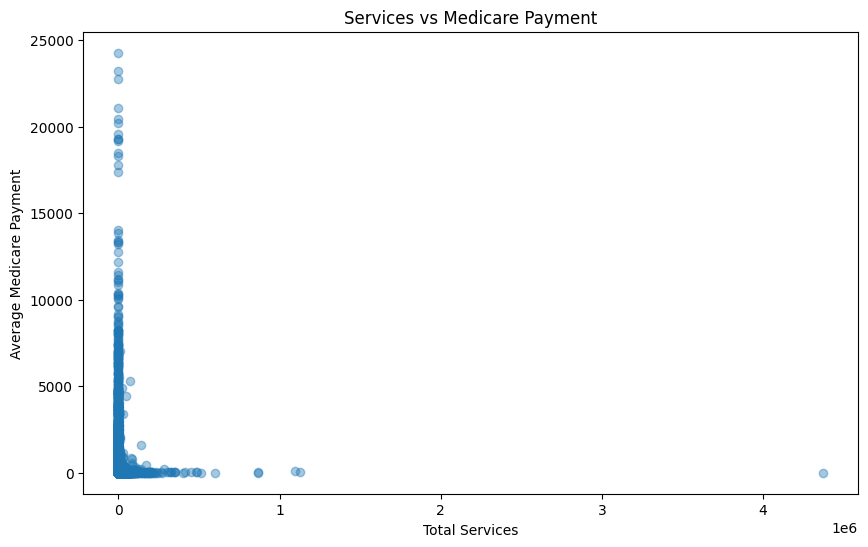

In [9]:
#Scatter Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df["total_services"],
    df["avg_medicare_payment"],
    alpha=0.4
)

plt.xlabel("Total Services")

plt.ylabel("Average Medicare Payment")

plt.title("Services vs Medicare Payment")

plt.show()